### Data Preprocessing

# **Mini Project 2 - CAPO TCS**
#### **Nik, Sal, and Samia (Team Pineapple)**

In [1]:
# Install the required libraries for Data Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Imports for Specific Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

In [3]:
# Imports for Splitting Data and Building Pipeline
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn import set_config
set_config(display='diagram')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [4]:
# Imports for Performance Measures
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [367]:
data = pd.read_csv('capo_data.csv')

data.head()

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day6test___wbc,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral
0,16,43.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,0,1,0,0,1,1,1,1
1,17,60.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,18,45.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,0,0,0,0,0,0,0,0
3,19,35.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
4,20,61.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [368]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8230 entries, 0 to 8229
Data columns (total 100 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   case_id                  8230 non-null   int64  
 1   dem_age                  8223 non-null   float64
 2   dem_sex                  8226 non-null   float64
 3   dem_pregnant             894 non-null    float64
 4   dem_trimester            19 non-null     float64
 5   exam_height              3213 non-null   float64
 6   exam_weight              3303 non-null   float64
 7   exam_hr                  5105 non-null   float64
 8   exam_rr                  3099 non-null   float64
 9   exam_sbp                 3623 non-null   float64
 10  exam_dbp                 3620 non-null   float64
 11  exam_temp                5113 non-null   float64
 12  exam_o2sat               3727 non-null   float64
 13  exam_o2satvalue          3444 non-null   float64
 14  exam_fio2              

In [369]:
#We have a bunch of columns that are missing the
#full 8230 rows in the dataset. The day test
#and case id values are all integers, otherwise, all
#other columns are floats. 
print(f'dataset is {data.shape[0]} by {data.shape[1]}')

dataset is 8230 by 100


In [370]:
# checking columns
data.columns

Index(['case_id', 'dem_age', 'dem_sex', 'dem_pregnant', 'dem_trimester',
       'exam_height', 'exam_weight', 'exam_hr', 'exam_rr', 'exam_sbp',
       'exam_dbp', 'exam_temp', 'exam_o2sat', 'exam_o2satvalue', 'exam_fio2',
       'exam_mental', 'lab_hematocrit', 'lab_hemoglobin', 'lab_wbc',
       'lab_bands', 'lab_platelets', 'lab_inr', 'lab_na', 'lab_k', 'lab_bun',
       'lab_creatinine', 'lab_bicarb', 'lab_glucose', 'lab_albumin', 'lab_ast',
       'lab_alt', 'lab_bilirubin', 'lab_trop1', 'lab_trop2', 'lab_trop3',
       'lab_ckmb1', 'lab_ckmb2', 'lab_ckmb3', 'lab_ldl', 'lab_hdl',
       'lab_cholesterol', 'lab_triglycerides', 'lab_lactate', 'lab_hga1c',
       'lab_ldh', 'lab_bnp', 'lab_crp', 'lab_pct', 'lab_vitamind', 'lab_abg',
       'lab_abgph', 'lab_abgpaco2', 'lab_abgpao2', 'lab_abgbicarb',
       'lab_abgfio2', 'cx_rul', 'cx_rml', 'cx_rll', 'cx_lul', 'cx_lll',
       'cx_db', 'cx_du', 'cx_cav', 'cx_pe', 'day0test___cough',
       'day0test___afebrile', 'day0test___wbc', 'day

In [371]:
#Check for null values in the data
data.isna().sum().sort_values(ascending=False)
data.isnull().sum()

case_id                       0
dem_age                       7
dem_sex                       4
dem_pregnant               7336
dem_trimester              8211
exam_height                5017
exam_weight                4927
exam_hr                    3125
exam_rr                    5131
exam_sbp                   4607
exam_dbp                   4610
exam_temp                  3117
exam_o2sat                 4503
exam_o2satvalue            4786
exam_fio2                  6388
exam_mental                 490
lab_hematocrit             4688
lab_hemoglobin             4902
lab_wbc                    3107
lab_bands                  8085
lab_platelets              4690
lab_inr                    8095
lab_na                     4684
lab_k                      4702
lab_bun                    5292
lab_creatinine             4728
lab_bicarb                 5993
lab_glucose                5007
lab_albumin                6235
lab_ast                    7634
lab_alt                    7602
lab_bili

In [373]:
# checking percentage of missing data
missing_percentage = (data.isnull().sum() / len(data))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

lab_vitamind               99.94%
lab_hga1c                  99.91%
dem_trimester              99.77%
lab_lactate                99.09%
lab_inr                    98.36%
lab_ckmb3                  98.31%
lab_bands                  98.24%
lab_bilirubin              97.34%
lab_ckmb2                  96.32%
lab_trop2                  95.02%
cx_du                      95.02%
cx_db                      94.84%
lab_pct                    93.69%
lab_bnp                    93.07%
lab_ast                    92.76%
lab_alt                    92.37%
lab_ldl                    92.27%
lab_hdl                    90.74%
lab_ckmb1                  89.44%
lab_triglycerides          89.38%
dem_pregnant               89.14%
lab_cholesterol            88.64%
lab_trop3                  87.21%
lab_trop1                  86.26%
lab_ldh                    84.53%
lab_abgfio2                79.94%
lab_abgph                  79.39%
exam_fio2                  77.62%
lab_albumin                75.76%
lab_abgpao2   

In [428]:
# checking percentage of missing data for all lab columns
lab_cols = data.filter(like='lab_')

missing_percentage = lab_cols.isnull().mean() * 100

missing_percentage.sort_values(ascending=False).map(lambda x: f"{x:.2f}%")

lab_vitamind         99.94%
lab_hga1c            99.91%
lab_lactate          99.09%
lab_inr              98.36%
lab_ckmb3            98.31%
lab_bands            98.24%
lab_bilirubin        97.34%
lab_ckmb2            96.32%
lab_trop2            95.02%
lab_pct              93.69%
lab_bnp              93.07%
lab_ast              92.76%
lab_alt              92.37%
lab_ldl              92.27%
lab_hdl              90.74%
lab_ckmb1            89.44%
lab_triglycerides    89.38%
lab_cholesterol      88.64%
lab_trop3            87.21%
lab_trop1            86.26%
lab_ldh              84.53%
lab_abgfio2          79.94%
lab_abgph            79.39%
lab_albumin          75.76%
lab_abgpao2          73.63%
lab_bicarb           72.82%
lab_abgbicarb        70.98%
lab_crp              70.87%
lab_abgpaco2         70.49%
lab_bun              64.30%
lab_glucose          60.84%
lab_hemoglobin       59.56%
lab_creatinine       57.45%
lab_k                57.13%
lab_platelets        56.99%
lab_hematocrit      

In [432]:
missing_percentage.sort_values(ascending=True).map(lambda x: f"{x:.2f}%")

lab_wbc              37.75%
lab_abg              55.24%
lab_na               56.91%
lab_hematocrit       56.96%
lab_platelets        56.99%
lab_k                57.13%
lab_creatinine       57.45%
lab_hemoglobin       59.56%
lab_glucose          60.84%
lab_bun              64.30%
lab_abgpaco2         70.49%
lab_crp              70.87%
lab_abgbicarb        70.98%
lab_bicarb           72.82%
lab_abgpao2          73.63%
lab_albumin          75.76%
lab_abgph            79.39%
lab_abgfio2          79.94%
lab_ldh              84.53%
lab_trop1            86.26%
lab_trop3            87.21%
lab_cholesterol      88.64%
lab_triglycerides    89.38%
lab_ckmb1            89.44%
lab_hdl              90.74%
lab_ldl              92.27%
lab_alt              92.37%
lab_ast              92.76%
lab_bnp              93.07%
lab_pct              93.69%
lab_trop2            95.02%
lab_ckmb2            96.32%
lab_bilirubin        97.34%
lab_bands            98.24%
lab_ckmb3            98.31%
lab_inr             

In [374]:
#Need to .dropna(how = '', axis = 0 for rows and 1 columns)
#and fillna some columns with mode and mean. 

In [375]:
#Dropping columns to leave only 'exam', 'dem', 'cx', and 'test' data per rubric.
data2 = data.drop(['lab_hematocrit', 'lab_hemoglobin', 'lab_bands', 'lab_platelets', 'lab_inr', 'lab_na', 'lab_k', 'lab_bun',
       'lab_creatinine', 'lab_bicarb', 'lab_glucose', 'lab_albumin', 'lab_ast',
       'lab_alt', 'lab_bilirubin', 'lab_trop1', 'lab_trop2', 'lab_trop3',
       'lab_ckmb1', 'lab_ckmb2', 'lab_ckmb3', 'lab_ldl', 'lab_hdl',
       'lab_cholesterol', 'lab_triglycerides', 'lab_lactate', 'lab_hga1c',
       'lab_ldh', 'lab_bnp', 'lab_crp', 'lab_pct', 'lab_vitamind', 'lab_abg',
       'lab_abgph', 'lab_abgpaco2', 'lab_abgpao2', 'lab_abgbicarb',
       'lab_abgfio2'], axis=1)
data2.columns

Index(['case_id', 'dem_age', 'dem_sex', 'dem_pregnant', 'dem_trimester',
       'exam_height', 'exam_weight', 'exam_hr', 'exam_rr', 'exam_sbp',
       'exam_dbp', 'exam_temp', 'exam_o2sat', 'exam_o2satvalue', 'exam_fio2',
       'exam_mental', 'lab_wbc', 'cx_rul', 'cx_rml', 'cx_rll', 'cx_lul',
       'cx_lll', 'cx_db', 'cx_du', 'cx_cav', 'cx_pe', 'day0test___cough',
       'day0test___afebrile', 'day0test___wbc', 'day0test___oral',
       'day1test___cough', 'day1test___afebrile', 'day1test___wbc',
       'day1test___oral', 'day2test___cough', 'day2test___afebrile',
       'day2test___wbc', 'day2test___oral', 'day3test___cough',
       'day3test___afebrile', 'day3test___wbc', 'day3test___oral',
       'day4test___cough', 'day4test___afebrile', 'day4test___wbc',
       'day4test___oral', 'day5test___cough', 'day5test___afebrile',
       'day5test___wbc', 'day5test___oral', 'day6test___cough',
       'day6test___afebrile', 'day6test___wbc', 'day6test___oral',
       'day7test___cough', '

In [376]:
#dropping all rows which sex and exam_mental is null
data2 = data2.dropna(subset=["dem_sex"])
data2 = data2.dropna(subset=["exam_mental"])

In [377]:
# Checking for amount of null values present
pd.set_option('display.max_rows', None)

data2.isnull().sum().sort_values(ascending=False)

dem_trimester              7721
cx_du                      7402
cx_db                      7395
dem_pregnant               6907
exam_fio2                  5951
exam_rr                    4782
exam_height                4765
exam_weight                4681
exam_o2satvalue            4436
exam_dbp                   4265
exam_sbp                   4262
exam_o2sat                 4162
exam_hr                    2779
exam_temp                  2770
lab_wbc                    2765
cx_rul                       35
cx_lul                       31
cx_rml                       29
cx_lll                       28
cx_rll                       28
cx_cav                       16
cx_pe                        11
dem_age                       1
dem_sex                       0
case_id                       0
exam_mental                   0
day0test___cough              0
day0test___afebrile           0
day0test___wbc                0
day0test___oral               0
day1test___cough              0
day1test

In [378]:
# checking percentage of missing data
missing_percentage = (data2.isnull().sum() / len(data2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

dem_trimester              99.75%
cx_du                      95.63%
cx_db                      95.54%
dem_pregnant               89.24%
exam_fio2                  76.89%
exam_rr                    61.78%
exam_height                61.56%
exam_weight                60.48%
exam_o2satvalue            57.31%
exam_dbp                   55.10%
exam_sbp                   55.06%
exam_o2sat                 53.77%
exam_hr                    35.90%
exam_temp                  35.79%
lab_wbc                    35.72%
cx_rul                      0.45%
cx_lul                      0.40%
cx_rml                      0.37%
cx_lll                      0.36%
cx_rll                      0.36%
cx_cav                      0.21%
cx_pe                       0.14%
dem_age                     0.01%
dem_sex                     0.00%
case_id                     0.00%
exam_mental                 0.00%
day0test___cough            0.00%
day0test___afebrile         0.00%
day0test___wbc              0.00%
day0test___ora

In [379]:
#Dropping these three columns due to insufficient quanity. 
data2 = data2.drop(['cx_du', 'cx_db', 'exam_fio2'], axis=1)

In [380]:
#imputing missing values so that all there are no missing values
imputation_dict = {
    'dem_trimester': 0,
    'dem_pregnant': 0,
    'dem_age': data2['dem_age'].mean(),
    'exam_temp': data2['exam_temp'].mean(),
    'exam_hr': data2['exam_hr'].mean(),
    'exam_rr': data2['exam_rr'].mean(),
    'exam_sbp': data2['exam_sbp'].mean(),
    'exam_dbp': data2['exam_dbp'].mean(),
    'exam_o2satvalue': data2['exam_o2satvalue'].mean(),
    'exam_height': data2['exam_height'].mean(),
    'exam_weight': data2['exam_weight'].mean(),
    'lab_wbc': data2['lab_wbc'].mean(),

    'exam_o2sat': data2['exam_o2sat'].mode()[0],
    'cx_rul': data2['cx_rul'].mode()[0],
    'cx_lul': data2['cx_lul'].mode()[0],
    'cx_rml': data2['cx_rml'].mode()[0],
    'cx_rll': data2['cx_rll'].mode()[0],
    'cx_lll': data2['cx_lll'].mode()[0],
    'cx_cav': data2['cx_cav'].mode()[0],
    'cx_pe': data2['cx_pe'].mode()[0],
}
#Imputed the mean for continuous measures, mode for discrete measures, and 0 for pregnancy and trimester demographics 

In [381]:
# Checking if missing values were imputed
data3 = data2.fillna(value=imputation_dict)
data3.isnull().sum()

case_id                    0
dem_age                    0
dem_sex                    0
dem_pregnant               0
dem_trimester              0
exam_height                0
exam_weight                0
exam_hr                    0
exam_rr                    0
exam_sbp                   0
exam_dbp                   0
exam_temp                  0
exam_o2sat                 0
exam_o2satvalue            0
exam_mental                0
lab_wbc                    0
cx_rul                     0
cx_rml                     0
cx_rll                     0
cx_lul                     0
cx_lll                     0
cx_cav                     0
cx_pe                      0
day0test___cough           0
day0test___afebrile        0
day0test___wbc             0
day0test___oral            0
day1test___cough           0
day1test___afebrile        0
day1test___wbc             0
day1test___oral            0
day2test___cough           0
day2test___afebrile        0
day2test___wbc             0
day2test___ora

In [382]:
#Run this cell to save the changes made.
# data3.to_csv("CAPOEDA.csv", index = False)

In [383]:
data4 = pd.read_csv("CAPOEDA.csv")
data4.head(10)

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day6test___wbc,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral
0,16,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,0,0,1,0,0,1,1,1,1
1,17,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,0
2,18,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,0,0,0,0,0,0,0,0
3,19,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,1,1,1,1,1,1,1,1
4,20,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,0
5,21,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,0,0,0,0,0,0,0,0
6,22,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,0
7,23,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,0
8,24,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,1,1,1,1
9,28,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,1,1,0,0,1,1,1,1


### Linear Regression Model - Predicting TCS
* Building a Linear Regression Model to to predict the Time to Clinical Stability (TCS) using the demographic, examination, and chest x-ray data 
* The Time to Clinical Stability (TCS) is defined by the first day the patient to achieve clinical stability. 
* This occurs when the patient meets all four criteria where 1 = Yes and 0 = No. If the patient meets all criteria for a given day (1111), the patient has a TSC score equivalent to that given day
* 4 criteria for achieving stability:
    * Improvement in cough/shortness of breath.
    * Temperature of less than 37.8C or 100F.
    * White blood cell counts of 10% or more lower than the previous day.
    * Whether the patient can eat or take pills orally.
* Discrete non-binary target variable: TCS = 1 - 8 

#### Creating Target Variable

In [384]:
# Creating a Target variable for Linear Regression Model

# Logic - Psuedocode:
# For Day 1: If 1111 --> TSC = 1 (Patient's Time to CLinical Stability TCS was achieved on Day 1)
# If not 1111, check if next day is 1111
# For Day 2: If 1111 --> TSC = 2 (Patient's Time to CLinical Stability TCS was achieved on Day 2)
# If not 1111, check if next day is 1111
# For Day 3: If 1111 --> TSC = 3 (Patient's Time to CLinical Stability TCS was achieved on Day 3)
# If not 1111, check if next day is 1111
# For Day 4: If 1111 --> TSC = 4 (Patient's Time to CLinical Stability TCS was achieved on Day 4)
# If not 1111, check if next day is 1111
# For Day 5: If 1111 --> TSC = 5 (Patient's Time to CLinical Stability TCS was achieved on Day 5)
# If not 1111, check if next day is 1111
# For Day 6: If 1111 --> TSC = 6 (Patient's Time to CLinical Stability TCS was achieved on Day 6)
# If not 1111, check if next day is 1111
# For Day 7: If 1111 --> TSC = 7 (Patient's Time to CLinical Stability TCS was achieved on Day 7)
# If not 1111 by Day 7, then TSC = 8 (Patient's Time to CLinical Stability TCS is assumed to be achieved on Day 8)


In [385]:
# creating function to calculate TCS Target variable for each patient if they achieved stabilitity for a given day by achieving 1 for all four criteria
def patient_tcs(row):
    # For day 1 to day 7
    for day in range(1, 8):
        criteria = [
            # criteria for improvement in cough/shortness of breath (Y/N) = (1/0)
            row[f'day{day}test___cough'],
            # criteria for temperature of less than 37.8C or 100F (Y/N) = (1/0)
            row[f'day{day}test___afebrile'],
            # criteria for white blood cell counts of 10% or more lower than the previous day (Y/N) = (1/0)
            row[f'day{day}test___wbc'],
            # criteria for whether the patient can eat or take pills orally (Y/N) = (1/0)
            row[f'day{day}test___oral'] 
        ]

        # Check if all criteria is met (1111) for the given day
        if all(x == 1 for x in criteria):
            return day
    # If patient does not achieve stability by day 7, TSC = 8
    return 8

In [386]:
# create the target column
data4['tcs_day_linear'] = data4.apply(patient_tcs, axis=1)

In [387]:
# viewing the column
data4.loc[3:30,['case_id','tcs_day_linear']]

,case_id,tcs_day_linear
3,19,4
4,20,4
5,21,4
6,22,3
7,23,2
8,24,8
9,28,8
10,29,3
11,30,2
12,31,1


In [388]:
data4.head(10)

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear
0,16,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,1,0,0,1,1,1,1,8
1,17,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,1
2,18,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,0,0,0,0,0,0,0,0,5
3,19,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,1,1,1,1,1,1,1,4
4,20,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,4
5,21,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,0,0,0,0,0,0,0,0,4
6,22,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,3
7,23,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,2
8,24,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,1,1,1,1,8
9,28,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,1,1,0,0,1,1,1,1,8


<Axes: ylabel='count'>

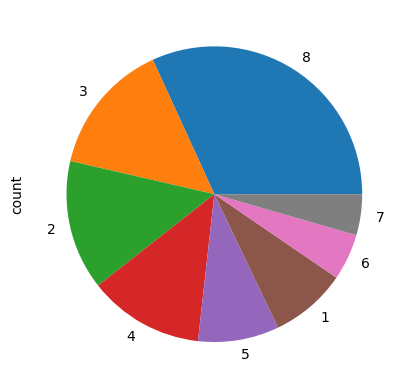

In [389]:
# visualizing the distribution of tcs scores for the data
data4['tcs_day_linear'].value_counts().plot(kind='pie')

In [390]:
data4['tcs_day_linear'].value_counts()

tcs_day_linear
8    2464
3    1127
2    1099
4     978
5     686
1     647
6     393
7     346
Name: count, dtype: int64

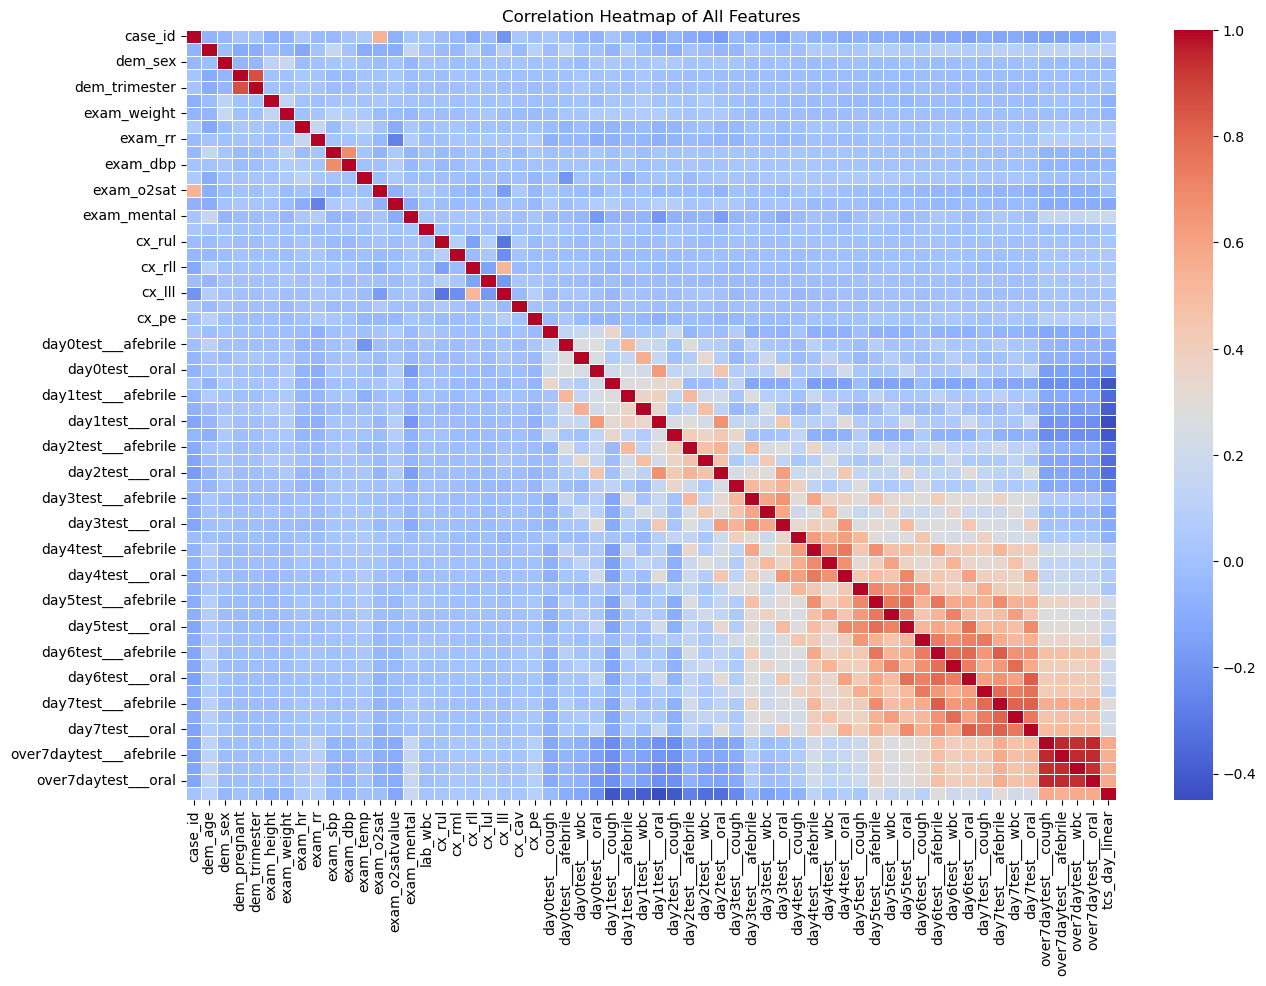

In [391]:
# Calculate the correlation matrix for all features of the dataset
corr_matrix = data4.corr()

# Set up the matplotlib figure size to accommodate many features
plt.figure(figsize=(15, 10))

# Create the heatmap
sns.heatmap(corr_matrix, 
            annot=False,        
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5)

plt.title('Correlation Heatmap of All Features')
plt.show()

In [392]:
data4_features = data4.drop(data4.columns[21:], axis=1)

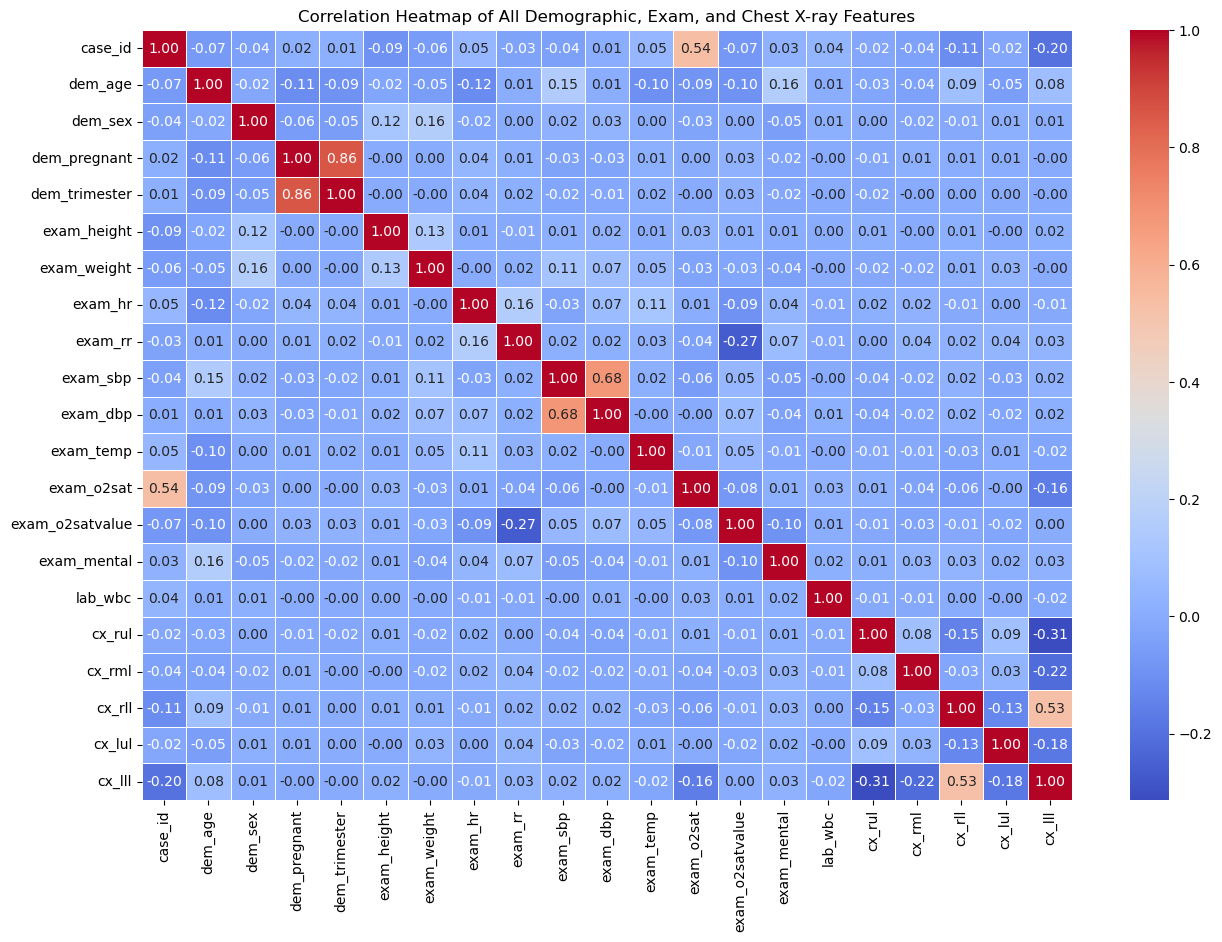

In [393]:
# Calculate the correlation matrix for all demographic, exam, and chest x-ray features of the dataset
corr_matrix = data4_features.corr()

# Set up the matplotlib figure size to accommodate many features
plt.figure(figsize=(15, 10))

# Create the heatmap
sns.heatmap(corr_matrix, 
            annot=True,        
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5)

plt.title('Correlation Heatmap of All Demographic, Exam, and Chest X-ray Features')
plt.show()

In [5]:
# creating copy of dataset to use for linear model
# data4.to_csv("CAPOEDA_LINEAR2.csv", index = False)

# loading data
data5 = pd.read_csv("CAPOEDA_LINEAR2.csv")
data5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7740 entries, 0 to 7739
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   case_id                  7740 non-null   int64  
 1   dem_age                  7740 non-null   float64
 2   dem_sex                  7740 non-null   float64
 3   dem_pregnant             7740 non-null   float64
 4   dem_trimester            7740 non-null   float64
 5   exam_height              7740 non-null   float64
 6   exam_weight              7740 non-null   float64
 7   exam_hr                  7740 non-null   float64
 8   exam_rr                  7740 non-null   float64
 9   exam_sbp                 7740 non-null   float64
 10  exam_dbp                 7740 non-null   float64
 11  exam_temp                7740 non-null   float64
 12  exam_o2sat               7740 non-null   float64
 13  exam_o2satvalue          7740 non-null   float64
 14  exam_mental             

In [6]:
# drop case_id and lab_wbc columns
data5 = data5.drop(['case_id', 'lab_wbc'], axis=1)

In [7]:
data5.head()

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,1,0,0,1,1,1,1,8
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,0,1
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,0,0,0,0,0,0,0,0,5
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,1,1,1,1,1,1,1,1,4
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,0,4


In [8]:
# dropping all columns which are not demographic, exam, or chest x-ray (cx) variables
data5 = data5.drop(data5.columns[21:-1], axis=1)

In [9]:
data5.head()

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,exam_o2satvalue,exam_mental,cx_rul,cx_rml,cx_rll,cx_lul,cx_lll,cx_cav,cx_pe,tcs_day_linear
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,8
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,5
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,4
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4


#### Splitting Data

In [10]:
# selecting explanatory variables (x) - demographic (dem_), exam (exam_) and chest x-ray (cx_) data
X = data5.drop(['tcs_day_linear'], axis=1)

In [11]:
X.head()

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,exam_o2sat,exam_o2satvalue,exam_mental,cx_rul,cx_rml,cx_rll,cx_lul,cx_lll,cx_cav,cx_pe
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,91.711562,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,91.711562,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [12]:
#selecting the tagret variable (y) - tcs score for patients
y = data5['tcs_day_linear']

In [13]:
y.head()

0    8
1    1
2    5
3    4
4    4
Name: tcs_day_linear, dtype: int64

In [14]:
# Split the data into Train/Test sets using 20% of the data for testing - 4 data frames X_train, X_test, y_train, and y_test
# setting arbitrary random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Training the Linear Regression Model and Executing

In [15]:
regressor=LinearRegression()

#Train your model
regressor.fit(X_train, y_train)

LinearRegression()

In [16]:
# Predict y values from the test data set and saving them to variable y_pred
y_pred = regressor.predict(X_test.values)

#### Evaluating Linear Regression Model

In [22]:
# Train set
y_train_pred = regressor.predict(X_train)
# calculate the mean squared error of the train set
mse_train = mean_squared_error(y_train, y_train_pred)
# calculate the root mean squared error of the train set
rmse_train = np.sqrt(mse_train)

print(f"MSE (train): {mse_train: .3f}")
print(f"RMSE (train): {rmse_train: .3f}")

# Test set
y_test_pred = regressor.predict(X_test)
# calculate the mean squared error of the train set
mse_test = mean_squared_error(y_test, y_test_pred)
# calculate the root mean squared error of the train set
rmse_test = np.sqrt(mse_test)

print(f"MSE (test): {mse_test: .3f}")
print(f"RMSE (test): {rmse_test: .3f}")

MSE (train):  5.832
RMSE (train):  2.415
MSE (test):  6.434
RMSE (test):  2.537


For Train set:
* We have a mean squared error of 5.832. This means our model's prediction deviates by approximately 5.832 units from the true TCS score.
* Our root mean squared error is 2.415.

For Test set:
* We have a mean squared error of 6.434. This means our model's prediction deviates by approximately 6.434 from the true TCS score.
* Our root mean squared error is 2.537.

Overall:
* Our train set had a better mean squared error (smaller value) as well as a root mean squared error (smaller value) in comparison to the test set. This is expected since the model is more "familiar" with the train set as it is what the model is actually training on so there is less likely for an error compared to the test set. Though the difference between the train set and test set is minimal.

In [407]:
# Calculate the R-squared value of the model (Test set only)
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.040850137929236086


We have an R-sqaured value of 4.09%. This implies that approximately 4.09% of the variation in the TCS score was describes by the explanatory features of demographics, exams, and chest x-ray results. This value indicates that the model performed poorly and that the explanatory features exhibit low predictive power for predicting the TCS score. 

A potential reasoning for the low accuracy may be due to the lack of variation within the explanatory features. Since most of the feature columns initially exhibited significant missing data, the utilization of the mean and mode were used to impute for the missing values. However, this imputation likely results in less variation within the feature columns. This lack of variation will inhibit the explanatory feature from accurately predicting the changes in the TCS, resulting in a low R-squared value.

In [19]:
# loading data
data6 = pd.read_csv("CAPOEDA_LINEAR2.csv")
data6.head()

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear
0,16,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,1,0,0,1,1,1,1,8
1,17,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,1
2,18,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,0,0,0,0,0,0,0,0,5
3,19,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,1,1,1,1,1,1,1,4
4,20,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,4


### Logistic Regression Model #1 - Stable vs. Not Stable
* Building a logistic regression model to predict whether the patient was stable or not stable using the same columns in the linear regression model
* Stable vs. Not Stable (Binary Target Variable)
* Patient achieved clinical stability within 7 days (TCS = 1 - 7)
    * Stable = 1 
* Patient did not achieve clinical stability within 7 days (TCS = 8) 
    * Not Stable = 0

#### Creating Target Variable

In [20]:
# Creating a Target variable for Logistic Regression Model

# Logic - Psuedocode:
# If the TCS is 1 - 7, the patient achieved stability so the stable_binary = 1 where tcs_day_linear <= 7
# If the TCS is not 1 - 7, then TCS = 8, so the patient did not achieve stability so the stable_binary = 0

In [21]:
# creating binary target variable
data6['stable_binary'] = (data6['tcs_day_linear'] <= 7).astype(int)

In [22]:
# cheacking if target variable added
data6.head(10)

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear,stable_binary
0,16,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,1,0,0,1,1,1,1,8,0
1,17,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,1,1
2,18,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,5,1
3,19,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,1,1,1,1,1,1,4,1
4,20,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,4,1
5,21,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,4,1
6,22,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,3,1
7,23,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,2,1
8,24,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,1,1,1,1,8,0
9,28,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,0,0,1,1,1,1,8,0


In [23]:
# drop case_id and lab_wbc columns
data6 = data6.drop(['case_id', 'lab_wbc'], axis=1)

In [24]:
data6.head(10)

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear,stable_binary
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,1,0,0,1,1,1,1,8,0
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,1,1
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,5,1
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,1,1,1,1,1,1,1,4,1
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,4,1
5,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,4,1
6,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,3,1
7,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,2,1
8,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,1,1,1,1,8,0
9,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,1,0,0,1,1,1,1,8,0


In [25]:
# dropping all columns which are not demographic, exam, or chest x-ray (cx) variables
data6 = data6.drop(data6.columns[21:-1], axis=1)

In [26]:
data6.head(10)

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,exam_o2satvalue,exam_mental,cx_rul,cx_rml,cx_rll,cx_lul,cx_lll,cx_cav,cx_pe,stable_binary
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
5,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
6,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
7,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
8,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0
9,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0


#### Splitting Data

In [27]:
# selecting explanatory variables (X2) - demographic (dem_), exam (exam_) and chest x-ray (cx_) data
X2 = data6.drop(['stable_binary'], axis=1)

In [28]:
X2.head()

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,exam_o2sat,exam_o2satvalue,exam_mental,cx_rul,cx_rml,cx_rll,cx_lul,cx_lll,cx_cav,cx_pe
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,91.711562,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,91.711562,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [29]:
#selecting the binary tagret variable (y2) - stable or not stable
y2 = data6['stable_binary']

In [30]:
y2.head()

0    0
1    1
2    1
3    1
4    1
Name: stable_binary, dtype: int64

In [31]:
# Split the data into Train/Test sets using 20% of the data for testing - 4 data frames X_train, X_test, y_train, and y_test
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

#### Training the Logistic Regression Model and Executing

In [32]:
classifier=LogisticRegression(max_iter=1000)
classifier.fit(X2_train.values,y2_train)

LogisticRegression(max_iter=1000)

In [33]:
# Predict y values from the test data set and saving them to variable y2_pred
y2_pred = classifier.predict(X2_test.values)

#### Evaluating Logistic Regression Model

* True Positive (TP) — model correctly predicts the positive class (prediction and actual both are positive).
* True Negative (TN) — model correctly predicts the negative class (prediction and actual both are negative).
* False Positive (FP) — model gives the wrong prediction of the negative class (predicted-positive, actual-negative)
* False Negative (FN) — model gives the wrong prediction of the positive class (predicted-negative, actual-positive). 

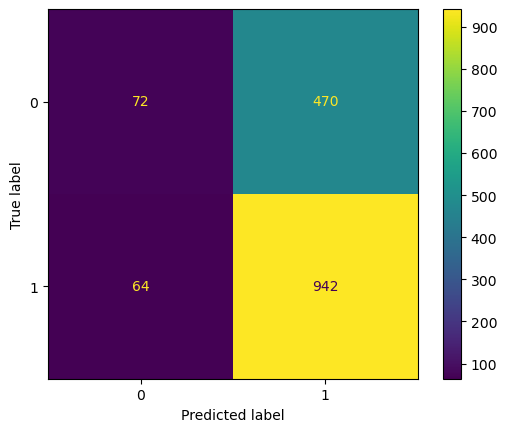

In [34]:
# viewing a confusion matrix
cm=confusion_matrix(y2_test, y2_pred)

disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()

Based on the confusion matrix. The logistic model performed poorly. This is because only 72 cases of a patient not achieving stability were correctly predicted by the model. However, an overwhelming 470 cases of a patient not achieving stability were incorrectly predicted to have achieved stability. Additionally, while 942 cases of patients were correctly predicted to have achieved stability, 64 cases of patients who achieved stability were incorrectly predicted to have not achieved stability.

In [35]:
# viewing the classification report
print(classification_report(y2_test,y2_pred))

              precision    recall  f1-score   support

           0       0.53      0.13      0.21       542
           1       0.67      0.94      0.78      1006

    accuracy                           0.66      1548
   macro avg       0.60      0.53      0.50      1548
weighted avg       0.62      0.66      0.58      1548



Based on the classification report:
* Precision Score: The Did Not Achieve Stability class (which is denoted by 0) has a fairly poor precision score of 0.53. The Achieved Stability class (which is denoted by 1) has a somewhat poor precision score of 0.67. These results indicate that the model had a relatively poor predictive performance for both classes though the predictive performance for Achieved Stability is slightly higher than Did Not Achieve Stability.
* Recall Score: The recall score is very high with a score of 0.94 for Achieved Stability and a signifcantly low score of 0.13 for Did Not Achieve Stability. This indicates that the model correctly captures the instances for Achieved Stability 94% of the time while it only correctly captured the instances for Did Not Achieve Stability 13% of the time.
* F1-Score: The model had a high F1 Score of 0.78 for Achieved Stability and a low F1 score of 0.21 for Did Not Achieve Stability. This indicates that overall there was a relatively good performance in the model for both precision and recall scores for the Achieved Stability class but not for the Did Not Achieve Stability class.
* The overall accuracy of the model was somewhat high at 66% however this is because the majority class was Achieved Stability which resulted in the predicted power of the model being skewed towards the Achieved Stability class. This means, the model is likely over-predicting the Achieved Stability class.

In [36]:
# compute the AUC
auc_score = roc_auc_score(y2_test, y2_pred)
print("The AUC Score:", auc_score)

The AUC Score: 0.5346115190774174


The Area Under the Curve (AUC) score of 53.46% indicates that the logistic regression model has very weak discriminative ability. This percentage suggests that the model is performing only marginally better than random chance in distinguishing between patients who achieved stability than those who did not achieve stability.

This means that if we randomly select one patient who achieved stability and one patient who did not achieve stability, the model will correctly assign a higher predicted probability to the Achieve Stability patient only about 53.46% of the time, which reflects poor overall predictive performance.

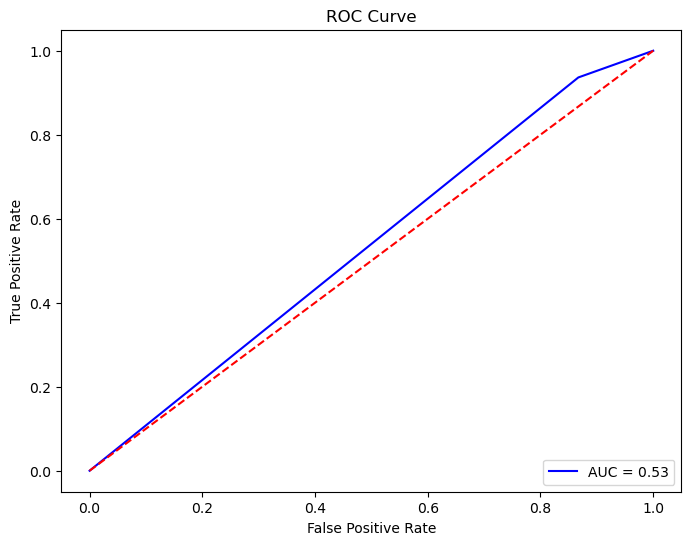

In [37]:
# Compute the ROC Curve points
fpr, tpr, thresholds = roc_curve(y2_test, y2_pred)

# plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

The blue Receiver-operating characteristic (ROC) curve almost overlaps the red diagonal which implies:
* The model has very weak class discrimination as confirmed by the AUC score
* The model struggles to separate Did Not Achieve Stability (Class 0) and Achieved Stability (Class 1)
* The model performance is only slightly better than chance

### Re-Running Logistic Regression Model #1 with Lab Data

In [38]:
# loading data
data6_2 = pd.read_csv("CAPOEDA_LINEAR2.csv")
data6_2.head()

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear
0,16,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,1,0,0,1,1,1,1,8
1,17,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,1
2,18,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,0,0,0,0,0,0,0,0,5
3,19,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,1,1,1,1,1,1,1,4
4,20,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,4


In [39]:
# creating binary target variable
data6_2['stable_binary2'] = (data6_2['tcs_day_linear'] <= 7).astype(int)

In [40]:
# drop case_id column
data6_2 = data6_2.drop(['case_id'], axis=1)

In [41]:
data6_2.head()

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear,stable_binary2
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,1,0,0,1,1,1,1,8,0
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,1,1
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,5,1
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,1,1,1,1,1,1,1,4,1
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,4,1


In [42]:
# dropping all columns which are not demographic, exam, chest x-ray (cx), or lab variables
data6_2 = data6_2.drop(data6_2.columns[22:-1], axis=1)

In [43]:
data6_2.head()

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,exam_mental,lab_wbc,cx_rul,cx_rml,cx_rll,cx_lul,cx_lll,cx_cav,cx_pe,stable_binary2
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1.0,18.470065,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,18.470065,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1.0,18.470065,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0.0,18.470065,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1.0,18.470065,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1


#### Splitting Data

In [44]:
# selecting explanatory variables (X3) - demographic (dem_), exam (exam_), chest x-ray (cx_), and lab data
X3 = data6_2.drop(['stable_binary2'], axis=1)

#selecting the binary tagret variable (y3) - stable or not stable
y3 = data6_2['stable_binary2']

# Split the data into Train/Test sets using 20% of the data for testing - 4 data frames X_train, X_test, y_train, and y_test
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

#### Training the Logistic Regression Model and Executing

In [45]:
classifier=LogisticRegression(max_iter=1000)
classifier.fit(X3_train.values,y3_train)

LogisticRegression(max_iter=1000)

In [46]:
# Predict y values from the test data set and saving them to variable y2_pred
y3_pred = classifier.predict(X3_test.values)

#### Evaluating Logistic Regression Model #1: Confusion Matrix Comparison (Before Including Lab Data and After Including Lab Data)

##### Recall: Confusion Matric Before Using Lab Data

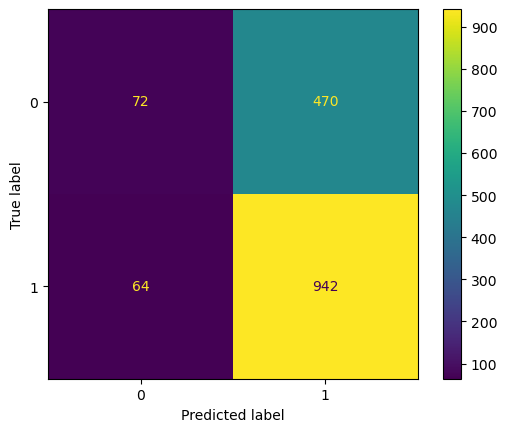

In [ ]:
# viewing a confusion matrix before adding lab data
cm=confusion_matrix(y2_test, y2_pred)

disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()

##### Confusion Matrix After Using Lab Data

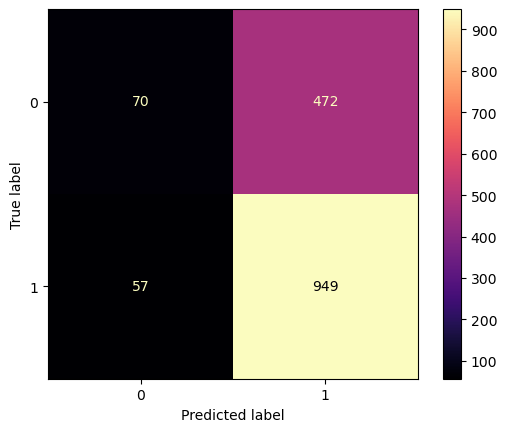

In [ ]:
# viewing a confusion matrix after adding lab data
cm2=confusion_matrix(y3_test, y3_pred)

disp=ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=classifier.classes_)
disp.plot(cmap=plt.cm.magma)
plt.show()

When comparing the confusion matrices before and after adding the lab data:
* We find that the number of cases where the model correctly predicted a patient Did Not Achieve Stability decreased from 72 (before adding lab data) to 70 (after adding lab data). Meaning that the number of cases where the model incorrectly predicted a patient Achieved Stability when the patient actually Did Not Achieve Stability increased from 470 (before adding lab data) to 472 (after adding lab data). This indicates worse performance.
* Additionally, We find that the number of cases where the model correctly predicted a patient Achieved Stability increased from 942 (before adding lab data) to 949 (after adding lab data). Meaning that the number of cases where the model incorrectly predicted a patient Did Not Achieve Stability when the patient actually Achieved Stability decreased from 64 (before adding lab data) to 57 (after adding lab data). This indicates better performance.
* Overall, comparing the confusion matrice show negligible change in model accuracy, though given that there was an increase in correct predictions of Achieved Stability, this implies the model accuracy improved slightly.

In [15]:
# viewing the classification report
print(classification_report(y3_test,y3_pred))

              precision    recall  f1-score   support

           0       0.55      0.13      0.21       542
           1       0.67      0.94      0.78      1006

    accuracy                           0.66      1548
   macro avg       0.61      0.54      0.50      1548
weighted avg       0.63      0.66      0.58      1548



In [16]:
# compute the AUC
auc_score = roc_auc_score(y3_test, y3_pred)
print("The AUC Score:", auc_score)

The AUC Score: 0.5362456258757419


#### Evaluating Logistic Regression Model #1: ROC Curve Comparison (Before Including Lab Data and After Including Lab Data)

##### Recall: ROC Curve Before Using Lab Data

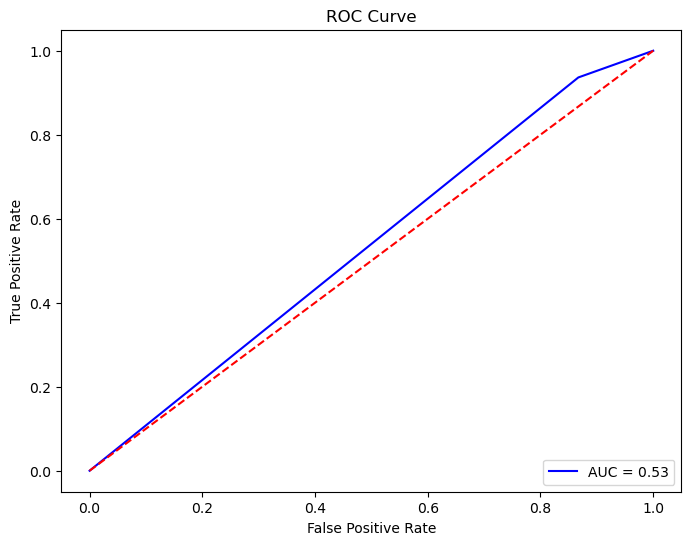

In [52]:
# Compute the ROC Curve points
fpr, tpr, thresholds = roc_curve(y2_test, y2_pred)

# plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

##### ROC Curve After Using Lab Data

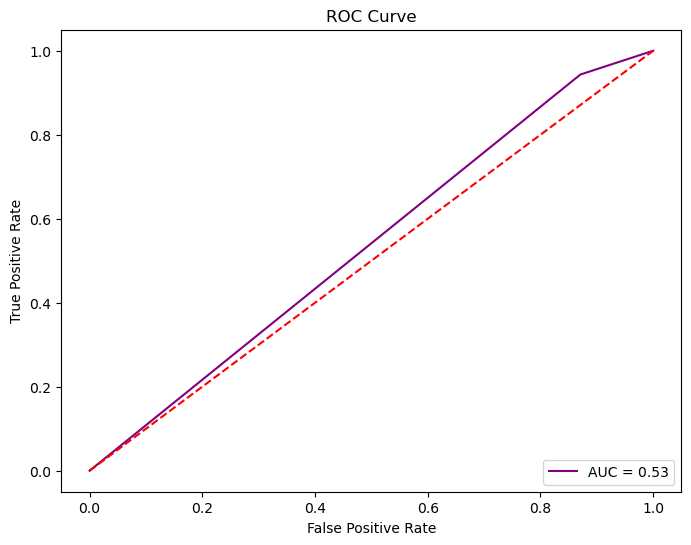

In [53]:
# Compute the ROC Curve points
fpr, tpr, thresholds = roc_curve(y3_test, y3_pred)

# plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='purple')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

When comparing the ROC Curves before and after adding the Lab data:
* Both curves exhibit similar patterns, which indicate negligble change in model accuracy

In [54]:
# loading data
data7 = pd.read_csv("CAPOEDA_LINEAR2.csv")
data7.head()

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear
0,16,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,1,0,0,1,1,1,1,8
1,17,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,1
2,18,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,0,0,0,0,0,0,0,0,5
3,19,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,1,1,1,1,1,1,1,4
4,20,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,4


### Logistic Regression Model #2 - Early Stability vs. Late Stability
* Building a logistic regression model to predict whether the patient achieved early stability or late stability using the same columns in the linear regression model
* Early Stability vs. Late Stability (Binary Target Variable)
* Patient achieved early stability (TCS = 1 - 3)
    * Early stability = 1 
* Patient achieed late stability (TCS = 4 - 8) 
    * Late Stability = 0

#### Creating Target Variable

In [55]:
# Creating a Target variable for Logistic Regression Model

# Logic - Psuedocode:
# If the TCS is 1 - 3, the patient achieved early stability so the early_binary = 1 where tcs_day_linear <= 3
# If the TCS is 4 - 8, the patient achieved late stability so the early_binary = 0

In [56]:
# creating binary target variable
data7['early_binary'] = (data7['tcs_day_linear'] <= 3).astype(int)

In [57]:
data7.head(10)

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear,early_binary
0,16,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,1,0,0,1,1,1,1,8,0
1,17,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,1,1
2,18,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,5,0
3,19,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,1,1,1,1,1,1,4,0
4,20,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,4,0
5,21,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,4,0
6,22,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,3,1
7,23,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,2,1
8,24,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,1,1,1,1,8,0
9,28,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,0,0,1,1,1,1,8,0


In [58]:
# drop case_id and lab_wbc columns
data7 = data7.drop(['case_id', 'lab_wbc'], axis=1)

In [59]:
# dropping all columns which are not demographic, exam, or chest x-ray (cx) variables
data7 = data7.drop(data7.columns[21:-1], axis=1)

#### Splitting Data

In [ ]:
# selecting explanatory variables (X4) - demographic (dem_), exam (exam_), chest x-ray (cx_), and lab data
X4 = data7.drop(['early_binary'], axis=1)

#selecting the binary tagret variable (y4) - stable or not stable
y4 = data7['early_binary']

# Split the data into Train/Test sets using 20% of the data for testing - 4 data frames X_train, X_test, y_train, and y_test
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)

#### Training the Logistic Regression Model and Executing

In [61]:
classifier=LogisticRegression(max_iter=1000)
classifier.fit(X4_train.values,y4_train)

LogisticRegression(max_iter=1000)

In [62]:
# Predict y values from the test data set and saving them to variable y2_pred
y4_pred = classifier.predict(X4_test.values)

#### Evaluating Logistic Regression Model #2

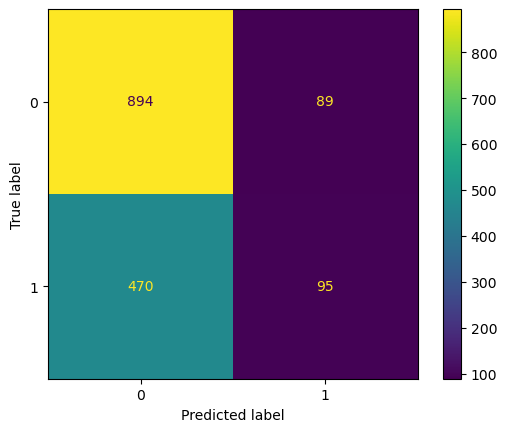

In [ ]:
# viewing a confusion matrix
cm3=confusion_matrix(y4_test, y4_pred)

disp=ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=classifier.classes_)
disp.plot()
plt.show()

Based on the confusion matrix. The logistic model performed poorly. This is because only 89 cases of a patient achieving late stability were incorrectly predicted by the model to have achieved early stability while an overwhelming 894 cases of a patient achieving late stability were correctly predicted to have achieved late stability. However, 470 cases of patients were incorrectly predicted to have not achieved late stability when they did in fact achieve early stability while only 95 cases of patients who achieved late stability were correctly predicted to have achieved late stability.

In [27]:
# viewing the classification report
print(classification_report(y4_test,y4_pred))

              precision    recall  f1-score   support

           0       0.66      0.91      0.76       983
           1       0.52      0.17      0.25       565

    accuracy                           0.64      1548
   macro avg       0.59      0.54      0.51      1548
weighted avg       0.60      0.64      0.58      1548



Based on the classification report:
* Precision Score: The Late Stability class (which is denoted by 0) has a moderate precision score of 0.66. The Early Stability class (which is denoted by 1) has a relatively poor precision score of 0.52. These results indicate that the model had a relatively poor predictive performance for both classes though the predictive performance for Late Stability is slightly higher than Early Stability.
* Recall Score: The recall score is very high with a score of 0.91 for Late Stability and a signifcantly low score of 0.17 for Eearly Stability. This indicates that the model correctly captures the instances for Late Stability 91% of the time while it correctly captured the instances for Early Stability only 17% of the time.
* F1-Score: The model had a high F1 Score of 0.76 for Late Stability and a low F1 score of 0.25 for Early Stability. This indicates that overall there was a relatively good performance in the model for both precision and recall scores for the Late Stability class but not for the Early Stability class.
* The overall accuracy of the model was somewhat high at 64% however this is because the majority class was Late Stability which resulted in the predicted power of the model being skewed towards the Late Stability class. This means, the model is likely over-predicting the Late Stability class.

In [29]:
# compute the AUC
auc_score = roc_auc_score(y4_test, y4_pred)
print("The AUC Score:", auc_score)

The AUC Score: 0.5388012135507162


The AUC score of 53.88% indicates that the logistic regression model has very weak discriminative ability though the AUC score is somewhat higher than the preview two logistic regression model, though this difference is negligible.

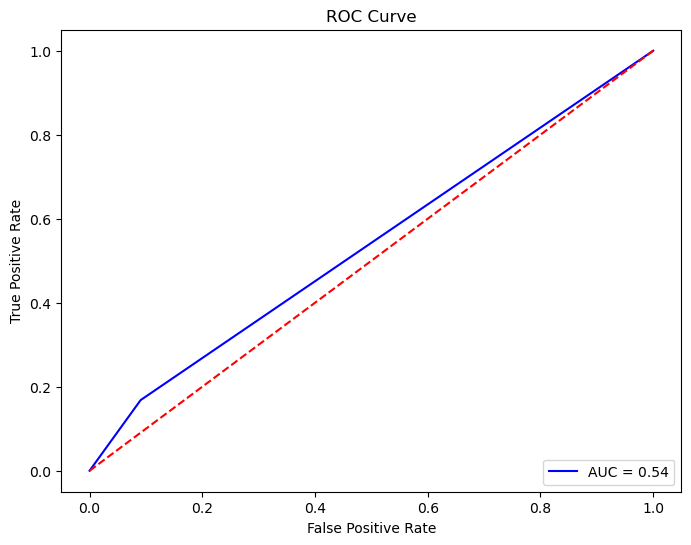

In [30]:
# Compute the ROC Curve points
fpr, tpr, thresholds = roc_curve(y4_test, y4_pred)

# plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

The blue Receiver-operating characteristic (ROC) curve almost overlaps the red diagonal which implies:
* The model has very weak class discrimination as confirmed by the AUC score
* The model struggles to separate Late Stability (Class 0) and Early Stability (Class 1)
* The model performance is only slightly better than chance
* The model exhibits similar accuracy to the previous two logistic regression models, though the accuracy is only slightly higher

### Re-Running Logistic Regression Model #2 with Lab Data

In [66]:
# loading data
data7_2 = pd.read_csv("CAPOEDA_LINEAR2.csv")

In [67]:
# creating binary target variable
data7_2['early_binary2'] = (data7_2['tcs_day_linear'] <= 3).astype(int)

In [68]:
# drop case_id column
data7_2 = data7_2.drop(['case_id'], axis=1)

# dropping all columns which are not demographic, exam, chest x-ray (cx), or lab variables
data7_2 = data7_2.drop(data7_2.columns[22:-1], axis=1)

In [69]:
# selecting explanatory variables (X5) - demographic (dem_), exam (exam_), chest x-ray (cx_), and lab data
X5 = data7_2.drop(['early_binary2'], axis=1)

#selecting the binary tagret variable (y5) - stable or not stable
y5 = data7_2['early_binary2']

# Split the data into Train/Test sets using 20% of the data for testing - 4 data frames X_train, X_test, y_train, and y_test
X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.2, random_state=42)

In [71]:
classifier=LogisticRegression(max_iter=1000)
classifier.fit(X5_train.values,y5_train)

# Predict y values from the test data set and saving them to variable y2_pred
y5_pred = classifier.predict(X5_test.values)

#### Evaluating Logistic Regression Model #2: Confusion Matrix Comparison (Before Including Lab Data and After Including Lab Data)

##### Recall: Confusion Matric Before Using Lab Data

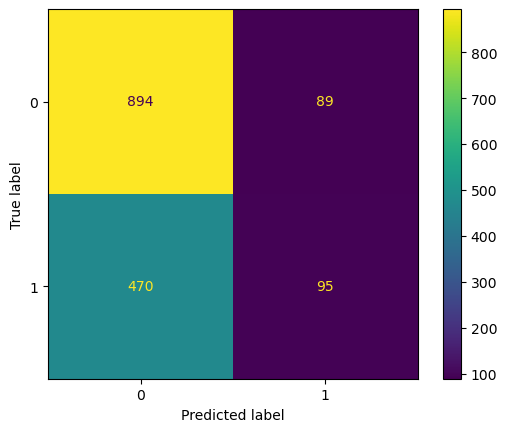

In [72]:
# viewing a confusion matrix before adding lab data
cm3=confusion_matrix(y4_test, y4_pred)

disp=ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=classifier.classes_)
disp.plot()
plt.show()

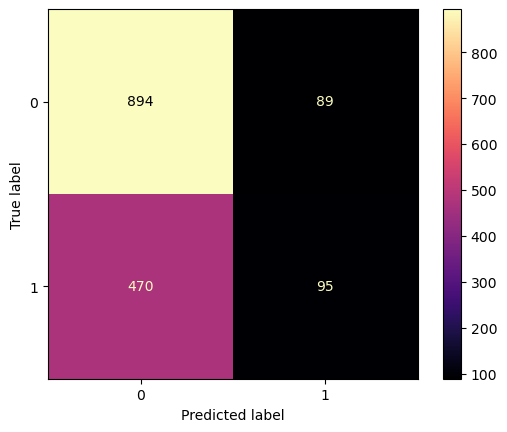

In [74]:
# viewing a confusion matrix after adding lab data
cm4=confusion_matrix(y4_test, y4_pred)

disp=ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=classifier.classes_)
disp.plot(cmap=plt.cm.magma)
plt.show()

When comparing the confusion matrices, the results from both models remained the same. This implies that adding the lab data did not have an effect on the model performance.

#### Evaluating Logistic Regression Model #2: ROC Curve Comparison (Before Including Lab Data and After Including Lab Data)

##### Recall: ROC Curve Before Using Lab Data

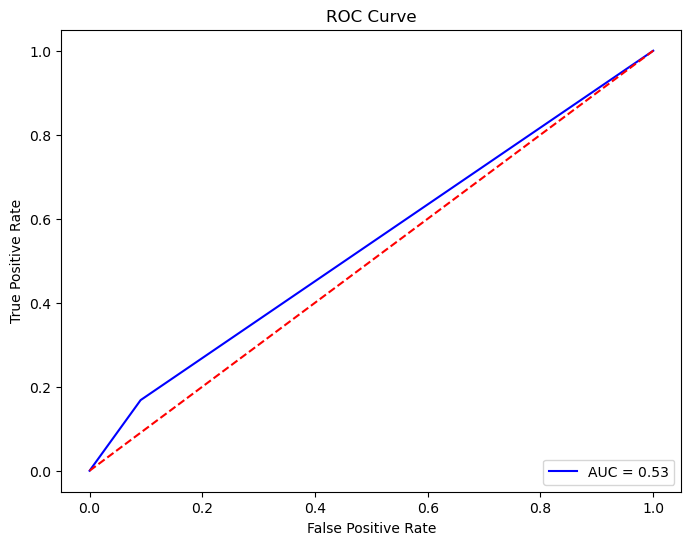

In [75]:
# Compute the ROC Curve points
fpr, tpr, thresholds = roc_curve(y4_test, y4_pred)

# plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

##### ROC Curve After Using Lab Data

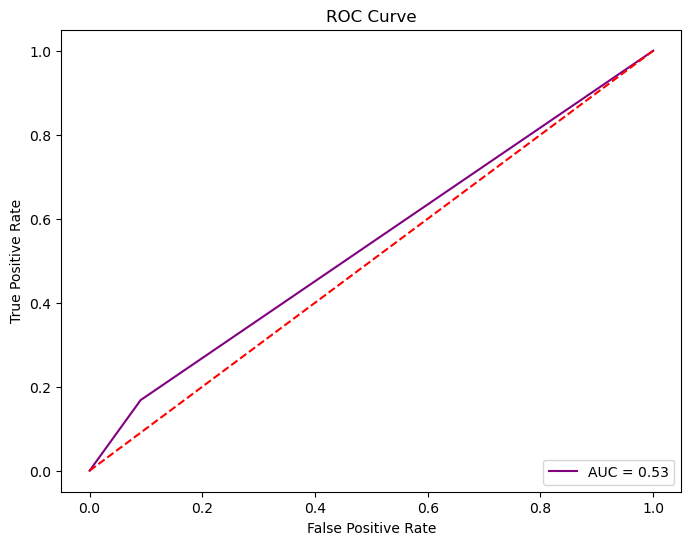

In [76]:
# Compute the ROC Curve points
fpr, tpr, thresholds = roc_curve(y5_test, y5_pred)

# plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='purple')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

When comparing the ROC curves, the model exhibited no change when lab data was added.

### **Conclusions**

* Overall when assessing the linear regression model to predict the time to clinical stability of patients, the model accuracy was strikingly low with a predictive accuracy of 4% based on the R-squared value. The cause of such low accuracy is likely due to the limited variability within explanatory features given that a large portion of these features exhibited missing values which were imputed with the mean or mode.
* When assessing logistic regression model #1 to predict whether a patient achieved stability or did not achieve stability, the model performed poorly based on the confusion matrix and classification report These results indicated that the predictive power was biased towards the achieved stability class. The AUC score and ROC curve shows that the model struggled to seperate the achieved stabilty class from the did not achieve stability class.
* When assessing logistic regression model #2 to predict whether a patient achieved early stability or late stability, the model performed poorly based on the confusion matrix and classification report These results indicated that the predictive power was biased towards the late stability class. The AUC score and ROC curve shows that the model struggled to seperate the early stabilty class from the late stability class.
* To improve the resuls for the logistic regression models #1 and #2 for future work, one can handle class imbalance using a combination of feature scaling to normalize all features as well as SMOTE (oversampling minority class) which artificially inflates the minority class to balance out both classes.
* Overall, adding lab data did not have a major impact on the predictive performance for the logistic regression models #1 and #2 given the negligible differences in results. However, this was due to the fact that we only reserved one lab feature. For future work, we will try to keep additional lab columns to better assess the impact of adding lab data.